# Exercise 2: Poisson Equation

Solve the 2D Poisson equation for the gravitational potential Φ of a uniform-density disk: 

\begin{equation*}
    \nabla^2\phi = 4\pi G \rho(x,y),
\end{equation*}

with density:

\begin{equation}
    \rho(x, y) =
    \begin{cases}
        \rho_0 & \mathrm{if}\, r = \sqrt{x^2+y^2} < R\\
        0 & \mathrm{otherwise}.
    \end{cases}
\end{equation}

Use units where $4πGρ0 = 1$ and $R = 1$. The computational domain is $[−L, L] × [−L, L]$ with
$L = 3R$. 

Dirichlet boundary conditions are imposed using the analytic solution evaluated at the
boundary points.


With $4πGρ0 = 1$, the Poisson equation reduces to:

\begin{equation}
    \begin{cases}
        \nabla^2 \phi = 1 & \mathrm{inside\,the\,disk}\\
        \nabla^2 \phi = 0 & \mathrm{outside\,the\,disk}
    \end{cases}
\end{equation}

Using radial symmetry, the general solutions are:

\begin{equation}
    \begin{cases}
        \mathrm{inside\,(r \leq R)}: & \phi = \frac{r^2}{4} +  C_{\mathrm{in}} \\
        \mathrm{outside\,(r > R)}: & \phi = \frac{R^2}{2}\ln{(r)} +  C_{\mathrm{out}}
    \end{cases}
\end{equation}

The two constants are fixed by continuity of $\phi$ and $d\phi/dr$ at $r = R$. Matching derivatives: $\rm d\phi_{in}/dr = r/2$ and $\rm d\phi_{out}/dr = R^2/(2r)$, both equal $R/2$ at $r = R$, so the derivative condition is automatically satisfied. Continuity of $\phi$ at $r = R$ then gives one relation, and we choose the normalization $\phi(R) = 0$. With $R = 1$:

\begin{equation*}
    C_{\mathrm{in}} = -1/4 \,\,\,\,\,\,\,\,\,\,\,\,\,\, C_{\mathrm{out}} = 0.
\end{equation*}

Therefore, the complete analytical solution is given by:


\begin{equation}
    \begin{cases}
        \mathrm{inside\,(r \leq R)}: & \phi = \frac{1}{4}(r^2-1) \\
        \mathrm{outside\,(r > R)}: & \phi = \frac{1}{2}\ln{(r)}
    \end{cases}
\end{equation}

Note: inside, $\phi$ is parabolic in $r$ with minimum $-1/4$ at the centre. Outside, $\phi$ grows logarithmically. The slope is continuous at $r=1$ with $\rm d\phi/dr=1/2$ there.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [2]:
def phi_true(r):
    
    phi_t = np.zeros_like(r)
    
    phi_t[r < R] = (r[r < R]**2 - 1.0) / 4.0
    phi_t[r > R] = 0.5 * np.log(r[r > R])

    return phi_t

In [3]:
def apply_bc(phi, phi_bc):
    """
    Apply Dirichlet boundary conditions (u[L] = u[L-1] = 0)
    
    array (float) u: solution at time n
    
    returns:
    array (float): solution at time n with boundary conditions applied 
    """
    phi_work = phi.copy()

    phi_work[0, :] = phi_bc[0,:]
    phi_work[-1, :] = phi_bc[-1,:]
    phi_work[:, 0] = phi_bc[:, 0]
    phi_work[:, -1] = phi_bc[:, -1]
        
    return phi_work

def compute_residual(phi, S, h):
    """Compute residual: Laplacian(phi) - S on interior."""
    res = np.zeros_like(phi)
    phi_work = phi.copy()
    res = np.roll(phi_work, -1, axis = 0) + np.roll(phi_work, 1, axis = 0) + np.roll(phi_work, -1, axis = 1) + np.roll(phi_work, 1, axis = 1)
    res = res - 4*phi_work - h**2*S

    res = apply_bc(res, S)  #avoid using boundaries to set maximum residual
    return res


In [4]:
def jacobi(source, phi, h):
    phi_work = phi.copy()
    
    phi_work = 1/4*(np.roll(phi, -1, axis = 0) + np.roll(phi, +1, axis = 0) + np.roll(phi, -1, axis = 1) + np.roll(phi, +1, axis = 1) - h**2*source)

    return phi_work

def gauss_seidel(source, phi, h):
    phi_work = phi.copy()
    #need to do gauss seidel steps separately (can't use np.roll)
    for i in range(1, nx-1):
        for j in range(1, nx-1):
            phi_work[i, j] = 1/4*(phi_work[i+1, j] + phi_work[i-1, j] + phi_work[i, j+1] + phi_work[i, j-1] - h**2 * source[i, j])
    return phi_work

def SOR(source, phi, h, omega):

    phi_work = phi.copy()
    #need to do gauss seidel steps separately (can't use np.roll)
    for i in range(1, nx-1):
        for j in range(1, nx-1):
            phi_star = 1/4*(phi_work[i+1, j] + phi_work[i-1, j] + phi_work[i, j+1] + phi_work[i, j-1] - h**2 * source[i, j])
            phi_work[i, j] = (1 - omega) * phi_work[i, j] + omega * phi_star
    return phi_work

In [5]:
def model(dx, A, p):
    """ 
    Model function to obtain the slope of the error curve in log-log scale.
    array (float) dx: step size
    float A: constant factor
    float p: order of the method (slope in log-log scale)

    returns:
    array (float): estimated errors from step size
    """
    return A*dx**p

In [6]:
G = 6.67430e-11        
rho = 1/(4*np.pi*G)
R = 1.
L = 3.
nx = 51
h = 2.0 * L / (nx - 1)
x = np.linspace(-L, L, nx)
y = np.linspace(-L, L, nx)

In [7]:
X, Y = np.meshgrid(x,y, indexing='ij')
r = np.sqrt(X**2+Y**2)
source = np.zeros((nx, nx))
source[r < R] = 4*np.pi*G*rho

In [8]:
phi_exact = phi_true(r)

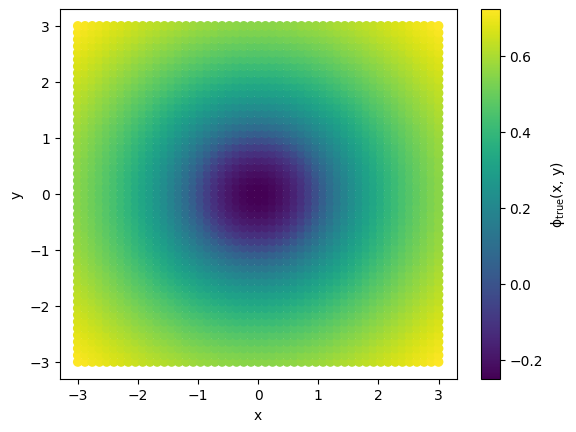

In [9]:
plt.scatter(X, Y, c = phi_exact)
plt.colorbar(label = r'$\rm\phi_{true}$(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [10]:
phi_jacobi = np.zeros_like(phi_exact)
phi_jacobi = apply_bc(phi_jacobi, phi_exact)
phi_old = phi_exact.copy()

err = 1.
i = 0
while err > 1e-6:
    phi_jacobi = jacobi(source, phi_jacobi, h)
    phi_jacobi = apply_bc(phi_jacobi, phi_exact)
    
    err = np.max(np.abs(compute_residual(phi_old, source, h)))
    phi_old = phi_jacobi.copy()
    i = i+1

print('Number of iterations:', i)

Number of iterations: 4030


In [11]:
phi_gs = np.zeros_like(phi_exact)
phi_gs = apply_bc(phi_gs, phi_exact)
phi_old = phi_exact.copy()

err = 1.
i = 0
while err > 1e-6:
    phi_gs = gauss_seidel(source, phi_gs, h)
    phi_gs = apply_bc(phi_gs, phi_exact)
    
    err = np.max(np.abs(compute_residual(phi_old, source, h)))
    phi_old = phi_gs.copy()
    i = i+1

print('Number of iterations:', i)

Number of iterations: 2012


In [12]:
phi_sor = np.zeros_like(phi_exact)
phi_sor = apply_bc(phi_sor, phi_exact)
phi_old = phi_exact.copy()

err = 1.
i = 0
omega = 2/(1+np.sin(np.pi/nx))
while err > 1e-6:
    phi_sor = SOR(source, phi_sor, h, omega)
    phi_sor = apply_bc(phi_sor, phi_exact)
    
    err = np.max(np.abs(compute_residual(phi_old, source, h)))
    phi_old = phi_sor.copy()
    i = i+1

print('Number of iterations:', i)

Number of iterations: 125


In [52]:
N = [20, 40, 80]

diff_list = []
err_list = []
errs = []
diff = []
for nx in N:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_jacobi = np.zeros_like(phi_exact)
    phi_jacobi = apply_bc(phi_jacobi, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    while err > 1e-6:
        phi_jacobi = jacobi(source, phi_jacobi, h)
        phi_jacobi = apply_bc(phi_jacobi, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_jacobi.copy()
        i = i+1
        
    print('Number of iterations:', i)    
    diff.append(i)
    err = np.max(np.abs(phi_jacobi-phi_exact))
    errs.append(err)

diff_list.append(diff)
err_list.append(errs)

Number of iterations: 718
Number of iterations: 2632
Number of iterations: 8919


In [53]:
N = [20, 40, 80]

diff = []
errs = []
for nx in N:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_gs = np.zeros_like(phi_exact)
    phi_gs = apply_bc(phi_gs, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    while err > 1e-6:
        phi_gs = gauss_seidel(source, phi_gs, h)
        phi_gs = apply_bc(phi_gs, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_gs.copy()
        i = i+1

    print('Number of iterations:', i)
    err = np.max(np.abs(phi_gs-phi_exact))
    diff.append(i)
    errs.append(err)

diff_list.append(diff)
err_list.append(errs)

Number of iterations: 362
Number of iterations: 1318
Number of iterations: 4462


In [54]:
N = [20, 40, 80]

diff = []
errs = []
for nx in N:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_sor = np.zeros_like(phi_exact)
    phi_sor = apply_bc(phi_sor, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    omega = 2/(1+np.sin(np.pi/nx))
    while err > 1e-6:
        phi_sor = SOR(source, phi_sor, h, omega)
        phi_sor = apply_bc(phi_sor, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_sor.copy()
        i = i+1

    print('Number of iterations:', i)
    
    diff.append(i)

    err = np.max(np.abs(phi_sor-phi_exact))
    errs.append(err)

diff_list.append(diff)
err_list.append(errs)

Number of iterations: 52
Number of iterations: 99
Number of iterations: 195


In [ ]:
N_iter = [50, 100, 500, 1000, 5000, 10000]
nx = 40

err_list = []
errs = []
for max_iter in N_iter:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_jacobi = np.zeros_like(phi_exact)
    phi_jacobi = apply_bc(phi_jacobi, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    while i < max_iter:
        phi_jacobi = jacobi(source, phi_jacobi, h)
        phi_jacobi = apply_bc(phi_jacobi, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_jacobi.copy()
        i = i+1

    print('Number of iterations:', i)
    err = np.max(np.abs(phi_jacobi-phi_exact))
    errs.append(err)

err_list.append(errs)

Number of iterations: 50
Number of iterations: 100
Number of iterations: 500
Number of iterations: 1000
Number of iterations: 5000
Number of iterations: 10000


: 

In [ ]:
diff = []
errs = []
for max_iter in N_iter:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_gs = np.zeros_like(phi_exact)
    phi_gs = apply_bc(phi_gs, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    while i < max_iter:
        phi_gs = gauss_seidel(source, phi_gs, h)
        phi_gs = apply_bc(phi_gs, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_gs.copy()
        i = i+1

    print('Number of iterations:', i)
    err = np.max(np.abs(phi_gs-phi_exact))
    errs.append(err)

err_list.append(errs)

Number of iterations: 50
Number of iterations: 100
Number of iterations: 500
Number of iterations: 1000
Number of iterations: 5000


In [ ]:
errs = []
for max_iter in N_iter:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_sor = np.zeros_like(phi_exact)
    phi_sor = apply_bc(phi_sor, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    omega = 2/(1+np.sin(np.pi/nx))
    while i < max_iter:
        phi_sor = SOR(source, phi_sor, h, omega)
        phi_sor = apply_bc(phi_sor, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_sor.copy()
        i = i+1

    print('Number of iterations:', i)
    err = np.max(np.abs(phi_sor-phi_exact))
    errs.append(err)

err_list.append(errs)

Number of iterations: 50
Number of iterations: 100
Number of iterations: 500
Number of iterations: 1000
Number of iterations: 5000


In [ ]:
N = np.array(N)
N_iter = np.array(N_iter)
diff_list = np.array(diff_list)
err_list = np.array(err_list)

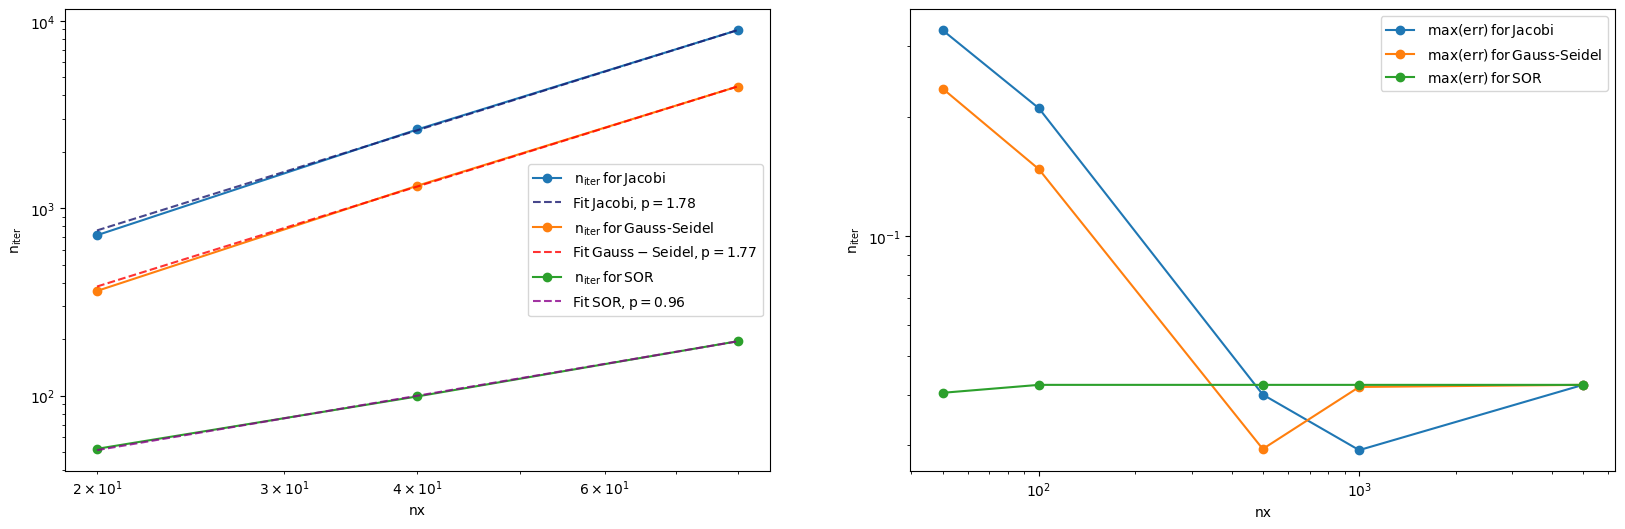

In [ ]:
fig = plt.figure(figsize = (20, 6))
ax = fig.add_subplot(121)

colors = ['midnightblue', 'red', 'darkmagenta']
labels = ['Jacobi', 'Gauss-Seidel', 'SOR']
for i in range(len(diff_list)):
    ax.loglog(N, diff_list[i], 'o-', label =  r'$\,\rm n_{iter}\, for\,$' +labels[i] )

    params, _ = curve_fit(model, N, diff_list[i])
    A_fit, p_fit = params
    ax.loglog(N, model(N, A_fit, p_fit), color = colors[i], linestyle = '--', alpha = 0.8, label=rf'$\rm Fit\, '+ labels[i]+f', p = {p_fit:.2f} $')
ax.set_xlabel('nx')
ax.set_ylabel(r'$\,\rm n_{iter}$')
ax.legend()


ax = fig.add_subplot(122)
for i in range(len(diff_list)):
    ax.loglog(N_iter, err_list[i], 'o-', label =  r'$\,\rm max(err)\, for\,$' +labels[i])

    #params, _ = curve_fit(model, N_iter, err_list[i], maxfev = int(1e6))
    #A_fit, p_fit = params
    #ax.loglog(N_iter, model(N_iter, A_fit, p_fit), color = colors[i], linestyle = '--', alpha = 0.8, label=rf'$\rm Fit\, '+ labels[i]+f', |p| = {-p_fit:.2f} $')
ax.set_xlabel('nx')
ax.set_ylabel(r'$\,\rm n_{iter}$')
ax.legend()

plt.show()